In [1]:
import os
import glob
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from collections import Counter

2025-10-09 10:30:16.436655: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


 ----------  A. Cargar y concatenar CSVs (si no lo has hecho) ----------

In [3]:
root_peth = '/home/javi/.cache/kagglehub/datasets/chethuhn/network-intrusion-dataset/versions/1/'

In [5]:
csv_files = glob.glob(os.path.join(root_peth, "*.csv"))
print("Archivos encontrados:", len(csv_files))

Archivos encontrados: 8


In [6]:
# Si los archivos son enormes, considera leer por chunks. Aquí asumo que tu máquina puede.
df_list = []
for f in csv_files:
    tmp = pd.read_csv(f)
    tmp.columns = tmp.columns.str.strip()  # normalizar nombres
    df_list.append(tmp)

In [7]:
df = pd.concat(df_list, ignore_index=True)

In [8]:
print("Tamaño del DF combinado:", df.shape)

Tamaño del DF combinado: (2830743, 79)


---------  B. Inspección breve ----------

In [9]:
df.columns[:100].tolist()

['Destination Port',
 'Flow Duration',
 'Total Fwd Packets',
 'Total Backward Packets',
 'Total Length of Fwd Packets',
 'Total Length of Bwd Packets',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Total',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Length',
 'Bwd Header Length',
 'Fwd Packets/s',
 'Bwd Packets/s',
 'Min Packet Length',
 'Max Packet Length',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Variance',
 'FIN Flag Count',
 'SYN Flag Count',
 'RST Flag Count',
 'PSH Flag Count',
 'ACK Flag Count',
 'UR

In [10]:
df.dtypes.value_counts()

int64      54
float64    24
object      1
Name: count, dtype: int64

In [11]:
df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

---------  C. Preprocesamiento ----------

In [12]:
# 1) Limpiar nombres y columnas innecesarias
df.columns = df.columns.str.strip()

In [13]:
# Quitar columnas no numéricas irrelevantes si existen (ej: Flow ID, Source IP, Timestamp)
to_drop = []
for c in ["Flow ID", "Source IP", "Destination IP", "Timestamp", "Flow ID "]:
    if c in df.columns:
        to_drop.append(c)
df = df.drop(columns=to_drop, errors='ignore')

In [14]:
# 2) Normalizar nombres de la etiqueta (en caso de caracteres raros)
if 'Label' in df.columns:
    df['Label'] = df['Label'].astype(str).str.strip()
else:
    raise KeyError("No se encontró la columna 'Label'. Usa df.columns para inspeccionar nombres exactos.")

In [15]:
# 3) Tratar valores infinitos o NaN
# Reemplaza inf por NaN y luego llenar o eliminar filas
df = df.replace([np.inf, -np.inf], np.nan)
nan_pct = df.isna().mean() * 100
print("Porcentaje NaN por columna (top 10):")
print(nan_pct.sort_values(ascending=False).head(10))

Porcentaje NaN por columna (top 10):
Flow Packets/s          0.101281
Flow Bytes/s            0.101281
Destination Port        0.000000
Average Packet Size     0.000000
Fwd Avg Bulk Rate       0.000000
Fwd Avg Packets/Bulk    0.000000
Fwd Avg Bytes/Bulk      0.000000
Fwd Header Length.1     0.000000
Avg Bwd Segment Size    0.000000
Avg Fwd Segment Size    0.000000
dtype: float64


In [16]:
# Opciones: eliminar filas con NaN en columnas críticas o imputar.
# Aquí vamos a eliminar filas con NaN en cualquiera de las features numéricas (puedes mejorar esto).
df = df.dropna(axis=0)
print("Tamaño tras dropna:", df.shape)

Tamaño tras dropna: (2827876, 79)


In [17]:
y = df['Label'].copy()
X = df.drop(columns=['Label'])

In [18]:
# Convertir columnas tipo object que sean numéricas (por si acaso)
for c in X.select_dtypes(include=['object']).columns:
    try:
        X[c] = pd.to_numeric(X[c])
    except:
        # si no se puede convertir (poco probable en este dataset), lo descartamos
        print(f"Descartando columna no convertible: {c}")
        X = X.drop(columns=[c])

In [19]:
# 5) Label encoding
le = LabelEncoder()
y_enc = le.fit_transform(y)
dict(zip(le.classes_, range(len(le.classes_))))

{'BENIGN': 0,
 'Bot': 1,
 'DDoS': 2,
 'DoS GoldenEye': 3,
 'DoS Hulk': 4,
 'DoS Slowhttptest': 5,
 'DoS slowloris': 6,
 'FTP-Patator': 7,
 'Heartbleed': 8,
 'Infiltration': 9,
 'PortScan': 10,
 'SSH-Patator': 11,
 'Web Attack � Brute Force': 12,
 'Web Attack � Sql Injection': 13,
 'Web Attack � XSS': 14}

In [20]:
# 6) Split train / test (estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.20, random_state=42, stratify=y_enc
)

In [21]:
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (2262300, 78) Test shape: (565576, 78)


In [22]:
# 7) Escalar features (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
# 8) Manejar desbalance con class weights
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_dict = {int(c): w for c, w in zip(classes, class_weights)}

In [24]:
class_weights_dict

{0: 0.08300244076266267,
 1: 96.370607028754,
 2: 1.472563952353056,
 3: 18.3167354870051,
 4: 0.8192331300007062,
 5: 34.285064787451695,
 6: 32.52533965926246,
 7: 23.758664146187776,
 8: 16757.777777777777,
 9: 5200.689655172414,
 10: 1.1871571042875246,
 11: 31.97371210515158,
 12: 125.05804311774462,
 13: 8871.764705882353,
 14: 288.9272030651341}

----------  D. Definir modelo Keras (densa) ----------

In [26]:
def build_model(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [27]:
input_dim = X_train_scaled.shape[1]
num_classes = len(le.classes_)

In [28]:
model = build_model(input_dim, num_classes)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │        40,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 210,191 (821.06 KB)

 Trainable params: 208,399 (814.06 KB)

 Non-trainable params: 1,792 (7.00 KB)

----------  E. Callbacks ----------

In [29]:
callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
]

----------  F. Entrenamiento ----------

In [30]:
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.15,
    epochs=50,
    batch_size=4096,           # ajustar según RAM/GPU
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=2
)

Epoch 1/50


2025-10-09 10:34:49.017324: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 599961960 exceeds 10% of free system memory.
2025-10-09 10:35:04.515339: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 105875640 exceeds 10% of free system memory.


470/470 - 16s - 34ms/step - accuracy: 0.4932 - loss: 1.3645 - val_accuracy: 0.6841 - val_loss: 1.1225 - learning_rate: 0.0010
Epoch 2/50
470/470 - 14s - 29ms/step - accuracy: 0.6403 - loss: 0.8090 - val_accuracy: 0.6583 - val_loss: 1.2214 - learning_rate: 0.0010
Epoch 3/50
470/470 - 14s - 29ms/step - accuracy: 0.6631 - loss: 0.6482 - val_accuracy: 0.6718 - val_loss: 1.1768 - learning_rate: 0.0010
Epoch 4/50
470/470 - 14s - 30ms/step - accuracy: 0.6944 - loss: 0.5185 - val_accuracy: 0.7231 - val_loss: 0.8372 - learning_rate: 0.0010
Epoch 5/50
470/470 - 14s - 29ms/step - accuracy: 0.7303 - loss: 0.5351 - val_accuracy: 0.7575 - val_loss: 0.7321 - learning_rate: 0.0010
Epoch 6/50
470/470 - 14s - 29ms/step - accuracy: 0.7418 - loss: 0.4948 - val_accuracy: 0.7669 - val_loss: 0.7072 - learning_rate: 0.0010
Epoch 7/50
470/470 - 14s - 29ms/step - accuracy: 0.7548 - loss: 0.4120 - val_accuracy: 0.7562 - val_loss: 0.7344 - learning_rate: 0.0010
Epoch 8/50
470/470 - 14s - 29ms/step - accuracy: 0.7

--------  G. Evaluación ----------

In [31]:
# Predicciones
y_pred_proba = model.predict(X_test_scaled, batch_size=4096)
y_pred = np.argmax(y_pred_proba, axis=1)

 20/139 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

2025-10-09 10:46:38.289647: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 176459712 exceeds 10% of free system memory.


139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [32]:
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Classification report:
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.88      0.94    454265
                       Bot       0.02      1.00      0.04       391
                      DDoS       0.86      1.00      0.93     25605
             DoS GoldenEye       0.62      0.97      0.76      2059
                  DoS Hulk       0.83      1.00      0.91     46025
          DoS Slowhttptest       0.63      0.99      0.77      1100
             DoS slowloris       0.50      0.99      0.66      1159
               FTP-Patator       0.47      0.99      0.64      1587
                Heartbleed       0.07      1.00      0.13         2
              Infiltration       0.00      0.71      0.00         7
                  PortScan       0.82      1.00      0.90     31761
               SSH-Patator       0.41      0.98      0.57      1180
  Web Attack � Brute Force       0.04      0.11      0.06       301
Web Attack � Sql Injecti

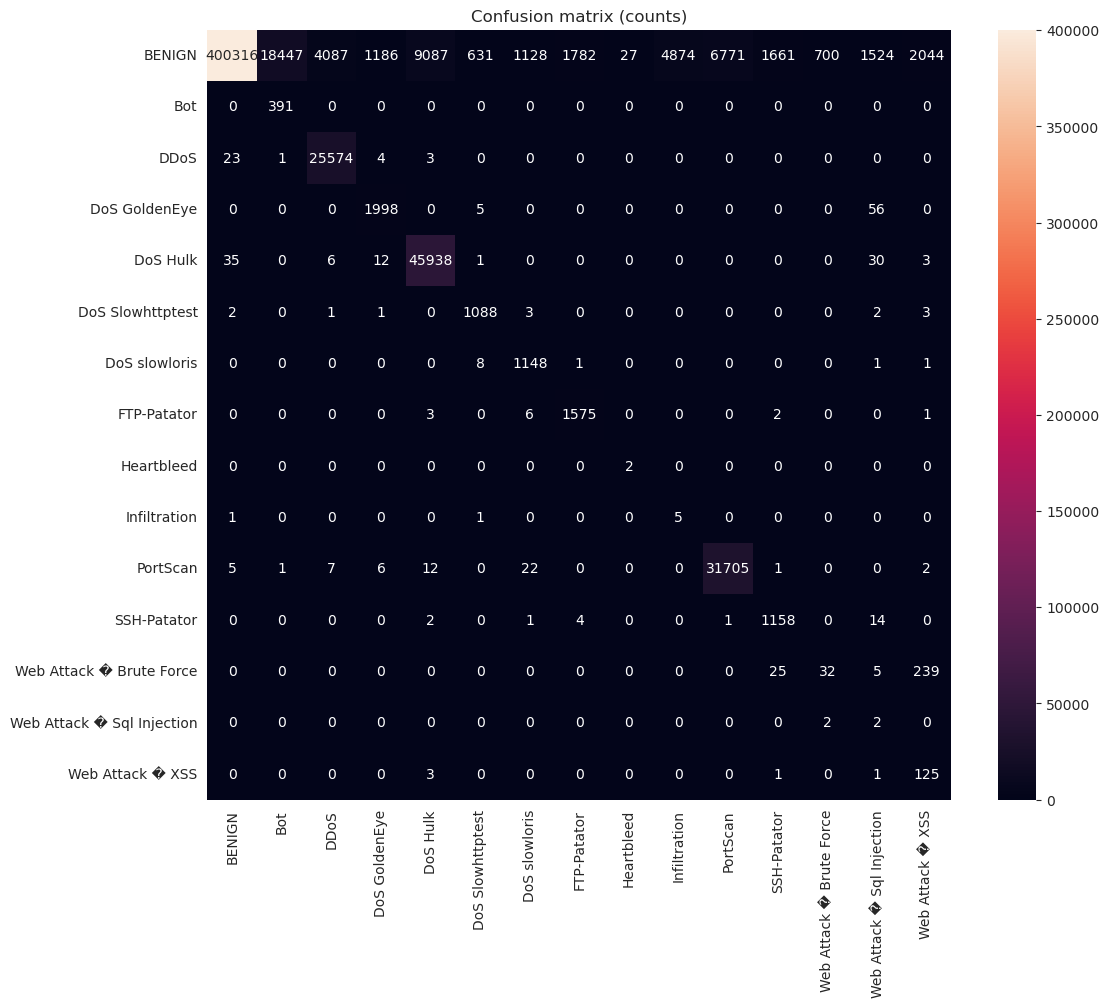

In [33]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='g', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion matrix (counts)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

--------  H. Guardar modelo y scaler ----------

In [34]:
model.save("cic_ids2017_nn_model.h5")
import joblib
joblib.dump(scaler, "scaler_cic_ids2017.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Modelo y artefactos guardados.")

Modelo y artefactos guardados.
